In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.table import Table
from datetime import datetime
import sys

# --- ADD THESE TWO LINES TO SUPPRESS WARNINGS ---
import warnings
from astropy.utils.exceptions import AstropyWarning
warnings.simplefilter('ignore', category=AstropyWarning)
# ------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.2)

def apply_masking(df, feature_cols, missing_rate=0.2):
    masked_df = df.copy()
    mask_dict = {}
    for col in feature_cols:
        mask = np.random.rand(len(df)) < missing_rate
        masked_df.loc[mask, col] = np.nan
        mask_dict[col] = mask
    return masked_df, df.copy(), mask_dict

def get_baseline_imputations(masked_df, feature_cols):
    print("Running Median Baseline...")
    median_imputer = SimpleImputer(strategy='median')
    df_median = pd.DataFrame(median_imputer.fit_transform(masked_df[feature_cols]), columns=feature_cols, index=masked_df.index)

    print("Running KNN Baseline...")
    knn = KNNImputer(n_neighbors=5)
    df_knn = pd.DataFrame(knn.fit_transform(masked_df[feature_cols]), columns=feature_cols, index=masked_df.index)
    
    print("Running MICE Baseline...")
    # Increased max_iter to 30 and slightly relaxed the tolerance
    mice = IterativeImputer(random_state=42, max_iter=30, tol=1e-3)
    df_mice = pd.DataFrame(mice.fit_transform(masked_df[feature_cols]), columns=feature_cols, index=masked_df.index)
    
    return df_median, df_knn, df_mice

def calculate_metrics(ground_truth, predicted_df, mask_dict, feature_cols, model_name):
    metrics = []
    for col in feature_cols:
        mask = mask_dict[col]
        if mask.sum() == 0: continue
        y_true = ground_truth.loc[mask, col]
        y_pred = predicted_df.loc[mask, col]
        metrics.append({
            'Model': model_name,
            'Feature': col,
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2': r2_score(y_true, y_pred)
        })
    return pd.DataFrame(metrics)

In [7]:
# ============================================================
# FITS CATALOGUE LOADING & METADATA EXTRACTION
# ============================================================

import os
import glob
import pandas as pd
from astropy.table import Table, vstack

DATA_DIR = "../Dataset"

def extract_fits_metadata(filepath):
    """Extracts columns, dtypes, and physical units directly from the FITS header."""
    try:
        table = Table.read(filepath)
        print(f"--- Metadata for: {os.path.basename(filepath)} ---")
        print(f"{'Feature Column':<30} | {'Data Type':<15} | {'Unit'}")
        print("-" * 75)
        for col in table.colnames:
            dtype = str(table[col].dtype)
            unit = str(table[col].unit) if table[col].unit else 'None'
            print(f"{col:<30} | {dtype:<15} | {unit}")
        print("\n")
    except Exception as e:
        print(f"Could not read metadata for {filepath}: {e}")

def load_fits_to_df(directory, skip_cluster=None, print_meta=False, save_fits_path=None):
    all_tables = []
    
    for filepath in glob.glob(f"{directory}/*.fits"):
        filename = os.path.basename(filepath)
        
        # Print metadata for the very first file found in this directory
        if print_meta:
            extract_fits_metadata(filepath)
            print_meta = False # Only print once per directory
            
        cluster_name = "unknown_cluster"
        if "cluster_" in filename:
            parts = filename.replace('.fits', '').split('_')
            for i, part in enumerate(parts):
                if part == 'cluster' and i + 1 < len(parts):
                    cluster_name = f"cluster_{parts[i+1]}"
                    break
        
        if skip_cluster and cluster_name == skip_cluster:
            continue
            
        # Read as Astropy Table
        table = Table.read(filepath)
        
        # Add the cluster column natively to the Astropy Table
        table['cluster'] = cluster_name 
        all_tables.append(table)
        
    if not all_tables:
        print(f"Warning: No FITS files loaded from {directory}")
        return pd.DataFrame()
        
    # Merge all Astropy Tables natively to preserve FITS metadata
    merged_table = vstack(all_tables)
    
    # Save the merged Astropy Table to a new FITS file if a path is provided
    if save_fits_path:
        print(f"Saving merged FITS to: {save_fits_path}")
        merged_table.write(save_fits_path, format='fits', overwrite=True)
        
    # Convert the final merged table to a Pandas DataFrame for your downstream ML pipeline
    return merged_table.to_pandas()


# ============================================================
# DATA EXECUTION
# ============================================================

print("Loading multi-cluster data catalogs (Skipping cluster_19)...")

gaia_df   = load_fits_to_df(f"{DATA_DIR}/Gaia", skip_cluster="cluster_19", print_meta=True)
xmm_df    = load_fits_to_df(f"{DATA_DIR}/XMM", skip_cluster="cluster_19", print_meta=True)

# Added the save_fits_path argument to save directly to the current notebook directory
arches_df = load_fits_to_df(
    f"{DATA_DIR}/Xmatch_Arches", 
    skip_cluster="cluster_19", 
    print_meta=True,
    save_fits_path="./merged_arches.fits" 
)

r_arches_fits_path = f"{DATA_DIR}/reduced_xmm_gaiadr3_xmatch_new_poserr_cluster_20.fits"
if os.path.exists(r_arches_fits_path):
    print(f"Loading verification dataset: {os.path.basename(r_arches_fits_path)}")
    
    extract_fits_metadata(r_arches_fits_path)
    
    r_arches_df = Table.read(r_arches_fits_path).to_pandas()
    r_arches_df["cluster"] = "cluster_20"
else:
    print(f"Warning: Verification file not found at {r_arches_fits_path}")
    r_arches_df = pd.DataFrame(columns=["cluster"])

print(f"Loaded Gaia Rows:          {len(gaia_df)}")
print(f"Loaded XMM Rows:           {len(xmm_df)}")
print(f"Loaded Arches Rows:        {len(arches_df)}")
print(f"Loaded Reduced Arches Rows: {len(r_arches_df)}")

Loading multi-cluster data catalogs (Skipping cluster_19)...
--- Metadata for: gaiadr3_cluster_0_3.fits ---
Feature Column                 | Data Type       | Unit
---------------------------------------------------------------------------
posRA                          | >f8             | deg
posDec                         | >f8             | deg
ePosA                          | >f8             | arcsec
ePosB                          | >f8             | arcsec
ePosPA                         | >f8             | deg
ePosEpoch                      | >f8             | yr
gaia_Source                    | >i8             | None
gaia_DR3Name                   | |S28            | None
gaia_RA_ICRS                   | >f8             | deg
gaia_DE_ICRS                   | >f8             | deg
gaia_e_RA_ICRS                 | >f8             | mas
gaia_e_DE_ICRS                 | >f8             | mas
gaia_RAJ2000                   | >f8             | deg
gaia_DEJ2000                   | >f8  

In [3]:
import os
import json
from datetime import datetime
import torch
import torch.nn as nn

# 1. Generate a single cohesive Run ID for this execution
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

# Feature Selection based on Cluster 20 metadata
selected_features = [
    'xmm_EP_8_RATE', 'xmm_SC_EP_8_FLUX', 
    'xmm_SC_HR1', 'xmm_SC_HR2', 'xmm_SC_HR3', 'xmm_SC_HR4', #'xmm_SC_EXTENT',
    'gaia_Gmag', 'gaia_BPmag', 'gaia_RPmag', 
    'gaia_Plx', 'gaia_Teff', 'gaia_logg',
    'gaia_pmRA', 'gaia_pmDE'
]
input_dim = len(selected_features)

class AstroMAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=32):
        super(AstroMAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AstroMAE(input_dim=input_dim).to(device)
print(f"Run ID: {run_id}")
print(f"AstroMAE initialized on {device} with {input_dim} features.")

Run ID: 20260607_080107
AstroMAE initialized on cuda with 14 features.


In [4]:
# # 1. Clean and Scale Data
# df_clean = r_arches_df.dropna(subset=selected_features).copy()
# print(f"Usable rows after dropping entirely missing records: {len(df_clean)}")

# scaler = StandardScaler()
# df_scaled_gt = pd.DataFrame(scaler.fit_transform(df_clean[selected_features]), 
#                             columns=selected_features, index=df_clean.index)

# # 2. Apply Artificial Mask (20% missing)
# df_masked, _, mask_dict = apply_masking(df_scaled_gt, selected_features, missing_rate=0.2)

# # 3. Calculate Baselines
# df_knn, df_mice = get_baseline_imputations(df_masked, selected_features)
# metrics_knn = calculate_metrics(df_scaled_gt, df_knn, mask_dict, selected_features, 'KNN')
# metrics_mice = calculate_metrics(df_scaled_gt, df_mice, mask_dict, selected_features, 'MICE')

# # 4. Train AstroMAE
# df_masked_filled = df_masked.fillna(0.0) # PyTorch needs numbers, 0.0 is the mean of scaled data
# X_masked_tensor = torch.tensor(df_masked_filled.values, dtype=torch.float32)
# X_clean_tensor = torch.tensor(df_scaled_gt.values, dtype=torch.float32)

# dataset = TensorDataset(X_masked_tensor, X_clean_tensor)
# dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# criterion = nn.MSELoss()

# print("\nTraining AstroMAE...")
# model.train()
# for epoch in range(100): # 100 epochs is a good start
#     for batch_masked, batch_clean in dataloader:
#         batch_masked, batch_clean = batch_masked.to(device), batch_clean.to(device)
#         optimizer.zero_grad()
#         loss = criterion(model(batch_masked), batch_clean)
#         loss.backward()
#         optimizer.step()
#     if (epoch + 1) % 20 == 0:
#         print(f"Epoch [{epoch+1}/100] | Loss: {loss.item():.4f}")

# # 5. Get AstroMAE Predictions
# model.eval()
# with torch.no_grad():
#     ssl_preds = model(X_masked_tensor.to(device)).cpu().numpy()
# df_ssl = pd.DataFrame(ssl_preds, columns=selected_features, index=df_clean.index)

# metrics_ssl = calculate_metrics(df_scaled_gt, df_ssl, mask_dict, selected_features, 'AstroMAE')
# print("\nExperiment Complete!")

In [5]:
# ==========================================
# CELL 4: The 24k MAE Training Loop (Huber + Masking + TQDM)
# ==========================================
from tqdm.notebook import tqdm

# 1. Isolate the full 24,000+ row dataset
df_base = arches_df[selected_features].copy()
print(f"Total rows in full Arches dataset: {len(df_base)}")

# Track where data ACTUALLY exists (so we don't calculate loss on natural NaNs)
valid_data_mask = ~df_base.isna()

# Fill natural NaNs with the column mean just to fit the StandardScaler
df_base_filled = df_base.fillna(df_base.mean())
scaler = StandardScaler()
df_scaled_gt = pd.DataFrame(scaler.fit_transform(df_base_filled), 
                            columns=selected_features, index=df_base.index)

# Put the natural NaNs back into the scaled ground truth
df_scaled_gt[~valid_data_mask] = np.nan

# 2. Apply Artificial Mask (20% missing completely at random)
df_masked, _, mask_dict = apply_masking(df_scaled_gt, selected_features, missing_rate=0.2)

# VERY IMPORTANT: Only evaluate metrics where we artificially masked AND ground truth exists
for col in selected_features:
    mask_dict[col] = mask_dict[col] & valid_data_mask[col]

# 3. Calculate Baselines (KNN and MICE)
df_median, df_knn, df_mice = get_baseline_imputations(df_masked, selected_features)
metrics_median = calculate_metrics(df_scaled_gt, df_median, mask_dict, selected_features, 'Median')
metrics_knn = calculate_metrics(df_scaled_gt, df_knn, mask_dict, selected_features, 'KNN')
metrics_mice = calculate_metrics(df_scaled_gt, df_mice, mask_dict, selected_features, 'MICE')

# 4. Train AstroMAE with Huber Loss
# Fill all NaNs (Natural + Artificial) with 0.0 (the standardized mean) for the network input
df_masked_filled = df_masked.fillna(0.0)
df_scaled_gt_filled = df_scaled_gt.fillna(0.0)

X_masked_tensor = torch.tensor(df_masked_filled.values, dtype=torch.float32)
X_clean_tensor = torch.tensor(df_scaled_gt_filled.values, dtype=torch.float32)
# Create a tensor mask of 1s and 0s for the Loss Function
Valid_mask_tensor = torch.tensor(valid_data_mask.values, dtype=torch.float32) 

dataset = TensorDataset(X_masked_tensor, X_clean_tensor, Valid_mask_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True) 

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
criterion = nn.HuberLoss(reduction='none', delta=1.0) 

print("\nTraining AstroMAE on full catalog...")
model.train()
num_epochs = 300
total_batches = len(dataloader)
print_interval = 30  # Leave a permanent status log every 30 epochs

for epoch in range(num_epochs):
    epoch_loss = 0.0
    current_epoch = epoch + 1
    
    for batch_idx, (batch_masked, batch_clean, batch_valid) in enumerate(dataloader, 1):
        batch_masked = batch_masked.to(device)
        batch_clean = batch_clean.to(device)
        batch_valid = batch_valid.to(device)
        
        optimizer.zero_grad()
        reconstructed = model(batch_masked)
        
        # Calculate Huber Loss per element
        raw_loss = criterion(reconstructed, batch_clean)
        
        # Zero out the loss where the original data was naturally a NaN
        masked_loss = raw_loss * batch_valid
        
        # Average the loss only over the valid elements
        loss = masked_loss.sum() / (batch_valid.sum() + 1e-8)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # In-line batch tracker (constantly overwrites itself on the current line)
        sys.stdout.write(f"\rEpoch {current_epoch:03d}/{num_epochs:03d} | Batch {batch_idx:02d}/{total_batches:02d} | Step Loss: {loss.item():.4f}")
        sys.stdout.flush()
        
    avg_epoch_loss = epoch_loss / total_batches
    scheduler.step(avg_epoch_loss)
    
    # --- Checkpoint Printing Logic ---
    # Print a permanent newline summary if it's a target interval OR the absolute last epoch
    if current_epoch % print_interval == 0 or current_epoch == num_epochs:
        sys.stdout.write(f"\r★ Epoch {current_epoch:03d}/{num_epochs:03d} Completed | Avg Huber Loss: {avg_epoch_loss:.6f}\n")
        sys.stdout.flush()
    else:
        # Otherwise, clear the batch ticker quietly at the end of the epoch to prepare for the next one
        sys.stdout.write(f"\rEpoch {current_epoch:03d}/{num_epochs:03d} Completed | Avg Huber Loss: {avg_epoch_loss:.6f}")
        sys.stdout.flush()

# 5. Get AstroMAE Predictions
print("\nRunning Inference...")
model.eval()
with torch.no_grad():
    # Pass the entire dataset in one go (24k rows is easily handled by GPU in a single pass)
    ssl_preds = model(X_masked_tensor.to(device)).cpu().numpy()
    
df_ssl = pd.DataFrame(ssl_preds, columns=selected_features, index=df_base.index)

metrics_ssl = calculate_metrics(df_scaled_gt, df_ssl, mask_dict, selected_features, 'AstroMAE')


# --- Unified Experiment Saving ---
models_dir = "Models"
os.makedirs(models_dir, exist_ok=True)

# 1. Save PyTorch Model State tagged with Run ID
model_filepath = os.path.join(models_dir, f"astromae_{run_id}.pth")
torch.save(model.state_dict(), model_filepath)
print(f"Model saved to: {model_filepath}")

# 2. Extract and structure your evaluation metrics
# Convert AstroMAE performance to a clean dictionary format
astromae_metrics = metrics_ssl.set_index('Feature')['R2'].to_dict()
mean_r2 = metrics_ssl['R2'].mean()

# 3. Build the Metadata Package
metadata = {
    "run_id": run_id,
    "timestamp": datetime.now().isoformat(),
    "input_dimension": input_dim,
    "selected_features": selected_features,
    "overall_mean_r2": mean_r2,
    "feature_r2_scores": astromae_metrics
}

# 4. Load existing manifest or initialize a new dictionary if it doesn't exist
manifest_filepath = os.path.join(models_dir, "master_manifest.json")

if os.path.exists(manifest_filepath):
    try:
        with open(manifest_filepath, 'r') as f:
            master_manifest = json.load(f)
    except json.JSONDecodeError:
        print("Warning: Master manifest was corrupted or empty. Initializing a new one.")
        master_manifest = {}
else:
    master_manifest = {}

# 5. Append the new run data indexed by its unique run_id
master_manifest[run_id] = metadata

# 6. Save the updated master manifest back to disk
with open(manifest_filepath, 'w') as f:
    json.dump(master_manifest, f, indent=4)

print(f"Experiment metadata successfully logged to master file: {manifest_filepath}")
# -----------------------------------------------------------------

print("Experiment Complete! You can now run Cell 5 to plot.")

Total rows in full Arches dataset: 24131
Running Median Baseline...
Running KNN Baseline...
Running MICE Baseline...


/usr/local/lib/python3.10/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:46: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Training AstroMAE on full catalog...
★ Epoch 030/300 Completed | Avg Huber Loss: 0.068038
★ Epoch 060/300 Completed | Avg Huber Loss: 0.065420
★ Epoch 090/300 Completed | Avg Huber Loss: 0.064291
★ Epoch 120/300 Completed | Avg Huber Loss: 0.061950
★ Epoch 150/300 Completed | Avg Huber Loss: 0.061479
★ Epoch 180/300 Completed | Avg Huber Loss: 0.060718
★ Epoch 210/300 Completed | Avg Huber Loss: 0.060281
★ Epoch 240/300 Completed | Avg Huber Loss: 0.059860
★ Epoch 270/300 Completed | Avg Huber Loss: 0.059472
★ Epoch 300/300 Completed | Avg Huber Loss: 0.059662

Running Inference...
Model saved to: Models/astromae_20260607_080107.pth
Experiment metadata successfully logged to master file: Models/master_manifest.json
Experiment Complete! You can now run Cell 5 to plot.


Plot successfully saved to: Plots/imputation_r2_scores_20260607_080107.png


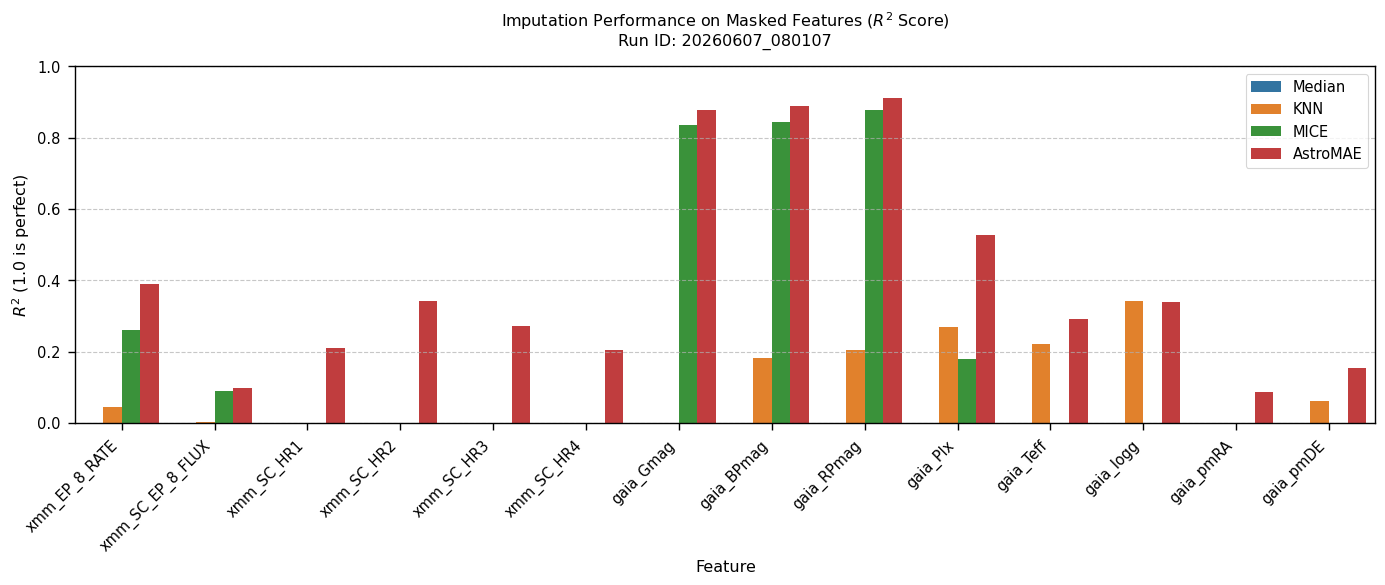


Mean R2 Score across all features:
Model
AstroMAE    0.399781
MICE        0.100062
KNN         0.038293
Median     -0.043152
Name: R2, dtype: float64

Feature R2 Scores Ranked (Highest to Lowest) per Model:

--- AstroMAE ---
gaia_RPmag           : 0.9122
gaia_BPmag           : 0.8885
gaia_Gmag            : 0.8792
gaia_Plx             : 0.5282
xmm_EP_8_RATE        : 0.3901
xmm_SC_HR2           : 0.3429
gaia_logg            : 0.3379
gaia_Teff            : 0.2919
xmm_SC_HR3           : 0.2711
xmm_SC_HR1           : 0.2103
xmm_SC_HR4           : 0.2031
gaia_pmDE            : 0.1552
xmm_SC_EP_8_FLUX     : 0.0988
gaia_pmRA            : 0.0875

--- MICE ---
gaia_RPmag           : 0.8769
gaia_BPmag           : 0.8448
gaia_Gmag            : 0.8353
xmm_EP_8_RATE        : 0.2616
gaia_Plx             : 0.1788
xmm_SC_EP_8_FLUX     : 0.0887
gaia_logg            : -0.0495
gaia_pmDE            : -0.0636
gaia_Teff            : -0.1118
xmm_SC_HR1           : -0.2001
xmm_SC_HR2           : -0.2014
xmm_S

In [6]:
# Combine all metrics (Now including Median)
all_metrics = pd.concat([metrics_median, metrics_knn, metrics_mice, metrics_ssl])

# Plot R2 Scores
plt.figure(figsize=(14, 6))
sns.barplot(data=all_metrics, x='Feature', y='R2', hue='Model')
plt.title(f'Imputation Performance on Masked Features ($R^2$ Score)\nRun ID: {run_id}', pad=15)
plt.ylabel('$R^2$ (1.0 is perfect)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.legend(loc='upper right') # Moved to upper right to avoid blocking short bars
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# --- Save the plot using the shared Run ID ---
plots_dir = "Plots"
os.makedirs(plots_dir, exist_ok=True)
plot_filename = os.path.join(plots_dir, f"imputation_r2_scores_{run_id}.png")
plt.savefig(plot_filename, dpi=300)
print(f"Plot successfully saved to: {plot_filename}")
# ----------------------------------------------

plt.show()

# Print text summary table for Overall Means
print("\nMean R2 Score across all features:")
print(all_metrics.groupby('Model')['R2'].mean().sort_values(ascending=False))

# --- NEW: Categorize and Rank Features per Model ---
print("\n" + "="*50)
print("Feature R2 Scores Ranked (Highest to Lowest) per Model:")
print("="*50)

# Loop through each model in the exact order of performance (best to worst)
model_order = all_metrics.groupby('Model')['R2'].mean().sort_values(ascending=False).index

for model_name in model_order:
    print(f"\n--- {model_name} ---")
    model_data = all_metrics[all_metrics['Model'] == model_name]
    
    # Sort the features by R2 descending
    ranked_features = model_data[['Feature', 'R2']].sort_values(by='R2', ascending=False)
    
    # Print formatted output
    for idx, row in ranked_features.iterrows():
        print(f"{row['Feature']:<20} : {row['R2']:.4f}")
print("\n" + "="*50)